In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets,models,layers
import matplotlib.pyplot as plt
import numpy as np


In [2]:
(x_train , y_train) ,(x_test , y_test) = datasets.fashion_mnist.load_data()

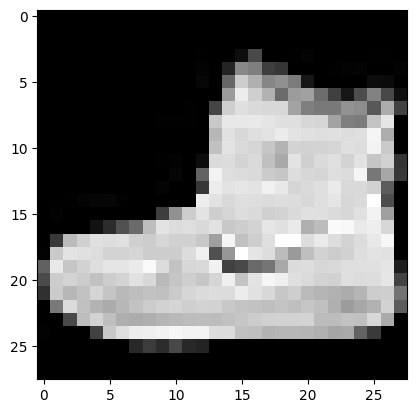

In [3]:
plt.imshow(x_train[0] , cmap='gray')

In [4]:
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

In [5]:
model = models.Sequential([
    layers.Conv2D(filters=32 , kernel_size=(3,3) , activation='relu' , input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=64 , kernel_size=(3,3) , activation='relu' , input_shape=(28,28,1)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.MaxPool2D((2,2)),


    layers.GlobalAveragePooling2D(),
    layers.Dense(64 , activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(10 , activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 26, 26, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 4, 4, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 1, 1, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,266 (94.79 KB)

 Trainable params: 23,946 (93.54 KB)

 Non-trainable params: 320 (1.25 KB)

In [7]:
model.compile(optimizer='nadam' , loss='sparse_categorical_crossentropy' , metrics=['sparse_categorical_accuracy'])

In [8]:
history = model.fit(x_train , y_train , epochs=150 , batch_size=128 , validation_data=(x_test , y_test))

Epoch 1/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 1.1068 - sparse_categorical_accuracy: 0.6363 - val_loss: 0.9903 - val_sparse_categorical_accuracy: 0.6839
Epoch 2/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4592 - sparse_categorical_accuracy: 0.8408 - val_loss: 0.3927 - val_sparse_categorical_accuracy: 0.8595
Epoch 3/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3845 - sparse_categorical_accuracy: 0.8659 - val_loss: 0.3584 - val_sparse_categorical_accuracy: 0.8732
Epoch 4/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.3519 - sparse_categorical_accuracy: 0.8765 - val_loss: 0.3737 - val_sparse_categorical_accuracy: 0.8647
Epoch 5/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3244 - sparse_categorical_accuracy: 0.8860 - val_loss: 0.3415 - val_sparse_categorical_accuracy: 0.8767
Epoch 6/150
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3046 - sparse_categorical_accuracy: 0.8914 - val_loss: 0.3693 - val_sparse_categorical_accuracy: 0.8

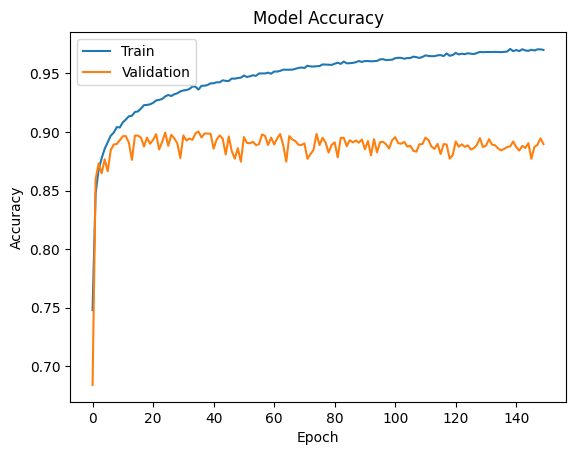

In [9]:
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train' , 'Validation'] , loc='upper left')
plt.show()